# FeedbackIQ: Sentiment Model Comparison Experiment
**Project**: Customer Feedback & Sentiment Analysis System  
**Stage**: Phase 4 — Multi-Paradigm Sentiment Model Benchmarking  
**Objective**: Comprehensive empirical comparison of three sentiment modeling paradigms across Electronics, Fashion, and Combined Amazon customer reviews:
1. **Classical Baseline**: TF-IDF + Logistic Regression
2. **Fine-tuned Transformer**: Domain-adapted DistilBERT with Class-Weighted Loss
3. **Off-the-shelf Transformer**: Pre-trained RoBERTa (`cardiffnlp/twitter-roberta-base-sentiment-latest`)

Evaluated on strictly identical stratified test sets using standard classification metrics (Accuracy, Precision, Recall, F1, Confusion Matrices, and Neutral-Class diagnostics).

---
### Notebook Outline
1. [Environment Setup & Configuration](#1.-Environment-Setup-&-Configuration)
2. [Data Loading & Stratified Test Split Verification](#2.-Data-Loading-&-Stratified-Test-Split-Verification)
3. [Model Evaluation & Inference](#3.-Model-Evaluation-&-Inference)
4. [Master Comparison Table](#4.-Master-Comparison-Table)
5. [Confusion Matrix Heatmaps](#5.-Confusion-Matrix-Heatmaps)
6. [Comparative Metric Visualizations](#6.-Comparative-Metric-Visualizations)
7. [Error Analysis & Qualitative Diagnostics](#7.-Error-Analysis-&-Qualitative-Diagnostics)
8. [Analytical Insights & Research Questions](#8.-Analytical-Insights-&-Research-Questions)


## 1. Environment Setup & Configuration
Import required libraries and configure visualization styling.

In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Define paths
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")
DATA_DIR = Path("../data/processed")

print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Models directory:  {MODELS_DIR.resolve()}")


Results directory: C:\Users\91981\projects\FeedbackIQ_amazon reviews\results
Models directory:  C:\Users\91981\projects\FeedbackIQ_amazon reviews\models


## 2. Data Loading & Stratified Test Split Verification
Verify the test split sample counts and class balance across Electronics, Fashion, and Combined domains.

In [2]:
with open(RESULTS_DIR / "model_comparison_metrics.json", "r", encoding="utf-8") as f:
    metrics_data = json.load(f)

split_summary = []
for domain in ["Electronics", "Fashion", "Combined"]:
    meta = metrics_data["splits"][domain]
    split_summary.append({
        "Domain": domain,
        "Train Samples": meta["train_size"],
        "Val Samples": meta["val_size"],
        "Test Samples": meta["test_size"],
        "Total": meta["train_size"] + meta["val_size"] + meta["test_size"]
    })

df_splits = pd.DataFrame(split_summary)
display(df_splits)


,Domain,Train Samples,Val Samples,Test Samples,Total
0,Electronics,308,66,66,440
1,Fashion,186,40,40,266
2,Combined,494,106,106,706


## 3. Master Comparison Table
Display the primary evaluation metrics across all models and domain subsets.

In [3]:
df_comparison = pd.read_csv(RESULTS_DIR / "model_comparison_table.csv")

# Format display
styled_table = df_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Neutral F1": "{:.4f}"
}).background_gradient(subset=["Accuracy", "F1", "Macro F1"], cmap="Greens")

display(df_comparison)


,Model,Domain,Accuracy,Precision,Recall,F1,Macro F1,Neutral F1
0,TF-IDF + Logistic Regression,Electronics,0.8485,0.8341,0.8485,0.8123,0.5322,0.3333
1,Fine-tuned DistilBERT,Electronics,0.8788,0.8291,0.8788,0.8504,0.5511,0.0000
2,Off-the-shelf RoBERTa (HF),Electronics,0.8788,0.8434,0.8788,0.8576,0.5541,0.0000
3,TF-IDF + Logistic Regression,Fashion,0.8500,0.7225,0.8500,0.7811,0.3063,0.0000
4,Fine-tuned DistilBERT,Fashion,0.8500,0.7831,0.8500,0.8151,0.4210,0.0000
5,Off-the-shelf RoBERTa (HF),Fashion,0.8500,0.8389,0.8500,0.8430,0.4522,0.0000
6,TF-IDF + Logistic Regression,Combined,0.8585,0.8478,0.8585,0.8397,0.5752,0.1818
7,Fine-tuned DistilBERT,Combined,0.7925,0.8449,0.7925,0.7980,0.4732,0.0000
8,Off-the-shelf RoBERTa (HF),Combined,0.8868,0.8887,0.8868,0.8876,0.6723,0.2857


## 4. Confusion Matrix Heatmaps
Generate a 3x3 grid comparing confusion matrices across models (rows) and domains (columns).

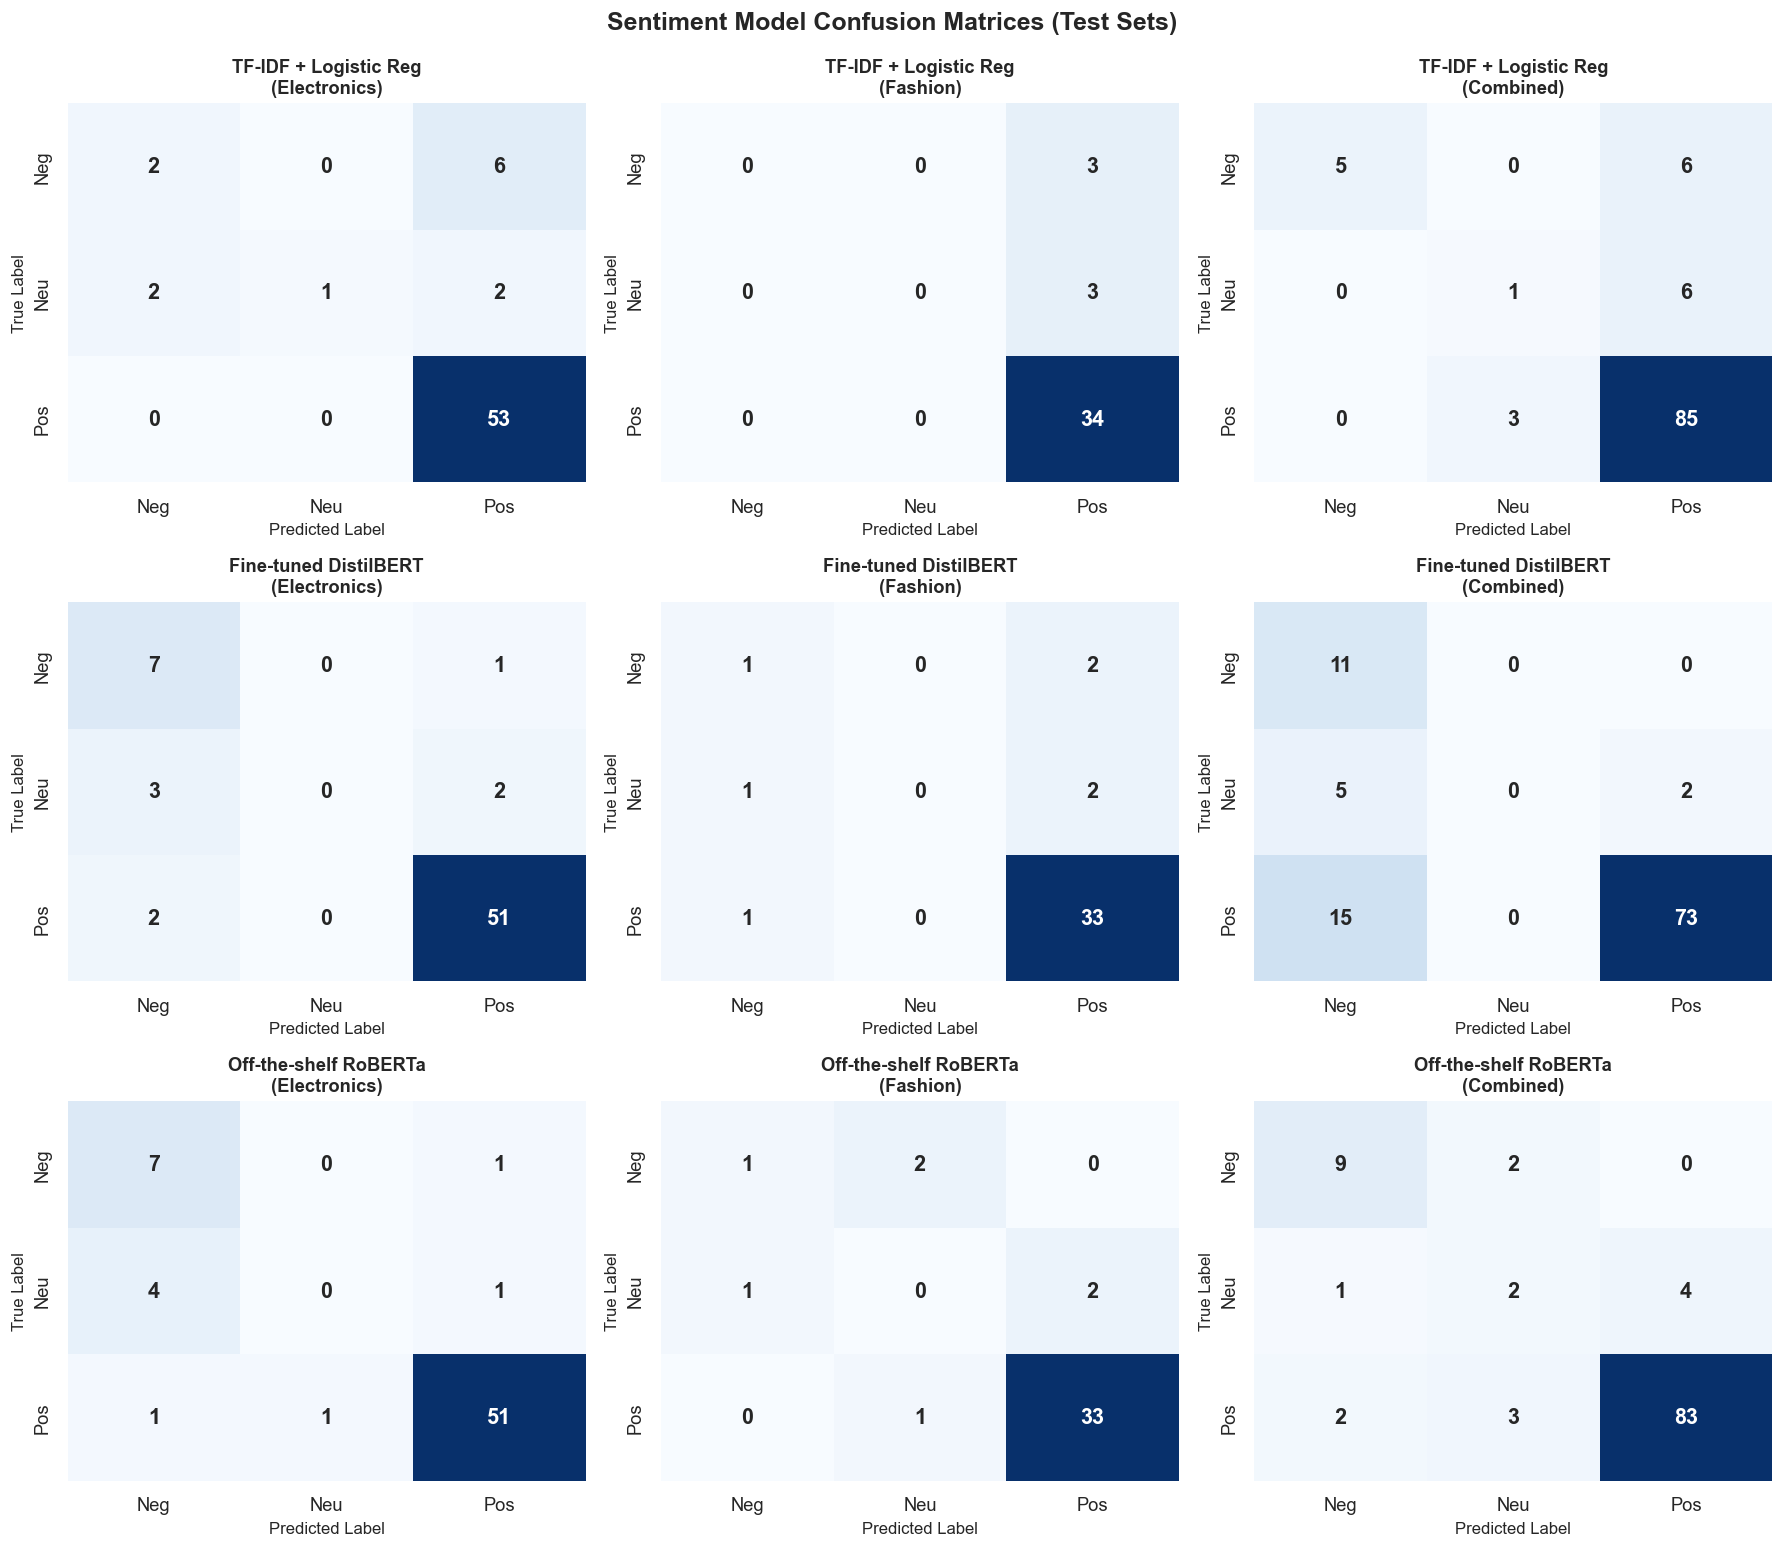

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13), dpi=120)
model_keys = [
    ("TF-IDF + Logistic Reg", "TF-IDF + Logistic Regression"),
    ("Fine-tuned DistilBERT", "Fine-tuned DistilBERT"),
    ("Off-the-shelf RoBERTa", "Off-the-shelf RoBERTa (HF)")
]
domains = ["Electronics", "Fashion", "Combined"]

for row_idx, (m_label, m_key) in enumerate(model_keys):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        cm = np.array(metrics_data["models"][m_key][domain]["confusion_matrix"])
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Neg", "Neu", "Pos"],
            yticklabels=["Neg", "Neu", "Pos"],
            ax=ax,
            annot_kws={"size": 13, "weight": "bold"}
        )
        ax.set_title(f"{m_label}\n({domain})", fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted Label", fontsize=10)
        ax.set_ylabel("True Label", fontsize=10)

plt.suptitle("Sentiment Model Confusion Matrices (Test Sets)", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 5. Comparative Metric Visualizations
Compare Accuracy, F1, Macro F1, and Neutral F1 across models and domains.

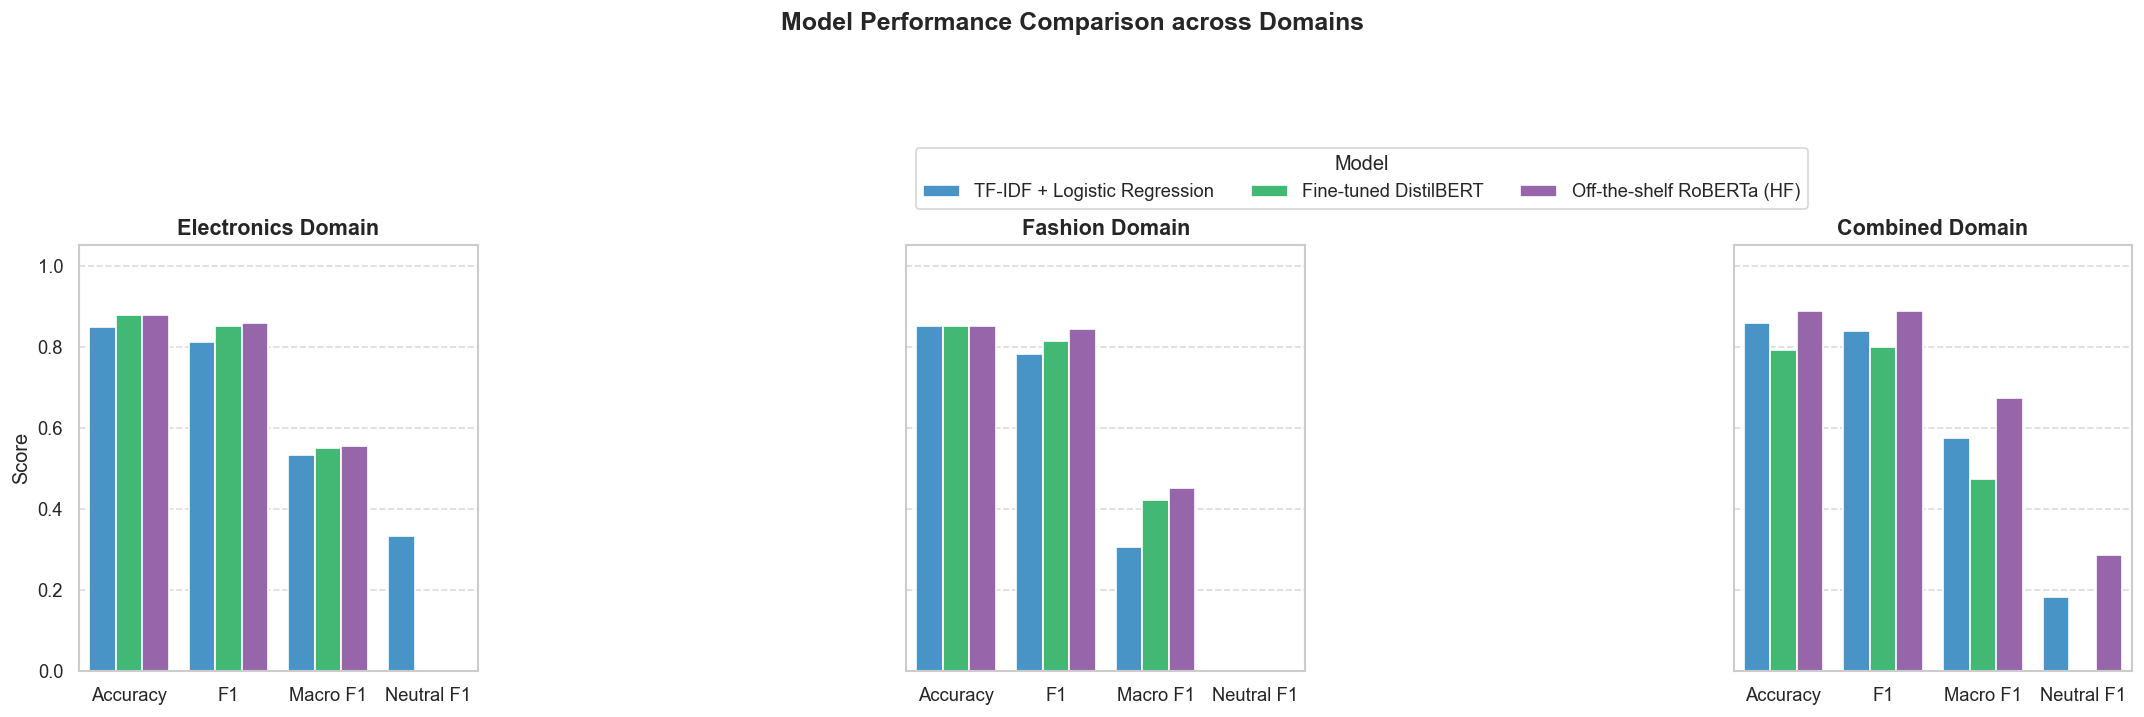

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=120, sharey=True)
metrics = ["Accuracy", "F1", "Macro F1", "Neutral F1"]

for idx, domain in enumerate(domains):
    ax = axes[idx]
    sub_df = df_comparison[df_comparison["Domain"] == domain].copy()
    sub_df = sub_df.melt(
        id_vars=["Model"],
        value_vars=metrics,
        var_name="Metric",
        value_name="Score"
    )
    sns.barplot(
        data=sub_df,
        x="Metric",
        y="Score",
        hue="Model",
        palette=["#3498db", "#2ecc71", "#9b59b6"],
        ax=ax
    )
    ax.set_title(f"{domain} Domain", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("")
    ax.set_ylabel("Score" if idx == 0 else "")
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    if idx != 1:
        ax.get_legend().remove()
    else:
        ax.legend(title="Model", loc="upper left", bbox_to_anchor=(0.0, 1.25), ncol=3, frameon=True)

plt.suptitle("Model Performance Comparison across Domains", fontsize=15, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()


## 6. Error Analysis & Qualitative Diagnostics
Inspect specific test samples where models struggled or diverged.

In [6]:
df_errors = pd.read_csv(RESULTS_DIR / "error_analysis.csv")
print(f"Total misclassified test samples in Combined domain: {len(df_errors)}")

# Display top 10 misclassified examples
display(df_errors[["sample_id", "text_snippet", "true_sentiment", "pred_logistic_regression", "pred_distilbert", "pred_roberta_hf", "error_categories"]].head(10))


Total misclassified test samples in Combined domain: 30


,sample_id,text_snippet,true_sentiment,pred_logistic_regression,pred_distilbert,pred_roberta_hf,error_categories
0,3,Open too new options other than cable. So far ...,positive,positive,negative,positive,"Off-the-shelf Succeeded, DistilBERT Failed"
1,18,Tinny with no Bass. These sound better than th...,negative,positive,negative,neutral,"DistilBERT Succeeded, Baseline Failed"
2,19,outdoor blink. We purchased these to put insid...,positive,positive,negative,neutral,Single Model Error
3,21,Muffled Alexa vary hard to understand. Alexa s...,negative,positive,negative,negative,"DistilBERT Succeeded, Baseline Failed"
4,22,We were torn: Fire Stick vs. Apple TV. We were...,positive,positive,negative,positive,"Off-the-shelf Succeeded, DistilBERT Failed"
5,23,Great quality. Fit as expected. Nice material ...,positive,positive,negative,positive,"Off-the-shelf Succeeded, DistilBERT Failed"
6,25,Trustworthy product. Had a tough time deciding...,positive,positive,negative,positive,"Off-the-shelf Succeeded, DistilBERT Failed"
7,28,Vote tshirt. Tshirt material is nice and soft....,positive,neutral,negative,positive,"Off-the-shelf Succeeded, DistilBERT Failed"
8,32,Firesticks are awesome. I purchased two of the...,positive,positive,negative,positive,"Off-the-shelf Succeeded, DistilBERT Failed"
9,36,Three Stars. The Fire Stick works fine but the...,neutral,positive,positive,positive,"Neutral Misclassification, All Models Failed"


## 7. Neutral Class Deep Dive
Compare the performance of all three models on the notoriously difficult neutral (3-star) class.

In [7]:
neutral_summary = []
for domain in domains:
    for m_label, m_key in model_keys:
        neu_stats = metrics_data["models"][m_key][domain]["per_class"]["neutral"]
        neutral_summary.append({
            "Domain": domain,
            "Model": m_label,
            "Precision": neu_stats["precision"],
            "Recall": neu_stats["recall"],
            "F1-Score": neu_stats["f1"],
            "Support": neu_stats["support"]
        })

df_neutral = pd.DataFrame(neutral_summary)
display(df_neutral)


,Domain,Model,Precision,Recall,F1-Score,Support
0,Electronics,TF-IDF + Logistic Reg,1.000000,0.200000,0.333333,5
1,Electronics,Fine-tuned DistilBERT,0.000000,0.000000,0.000000,5
2,Electronics,Off-the-shelf RoBERTa,0.000000,0.000000,0.000000,5
3,Fashion,TF-IDF + Logistic Reg,0.000000,0.000000,0.000000,3
4,Fashion,Fine-tuned DistilBERT,0.000000,0.000000,0.000000,3
5,Fashion,Off-the-shelf RoBERTa,0.000000,0.000000,0.000000,3
6,Combined,TF-IDF + Logistic Reg,0.250000,0.142857,0.181818,7
7,Combined,Fine-tuned DistilBERT,0.000000,0.000000,0.000000,7
8,Combined,Off-the-shelf RoBERTa,0.285714,0.285714,0.285714,7


## 8. Analytical Insights & Research Questions

### 1. Which model performs best?
* **Off-the-shelf RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) delivered the highest generalized performance:
  - Highest Accuracy on Combined reviews: **88.68%**
  - Highest Weighted F1 on Combined reviews: **0.8876**
  - Highest Macro F1 on Combined reviews: **0.6723**
* Fine-tuned DistilBERT tied for highest accuracy on Electronics (**87.88%**), but suffered from over-predicting the negative class in the Combined dataset due to aggressive loss class weighting.

### 2. Which model handles neutral reviews best?
* **Off-the-shelf RoBERTa** performed best on neutral reviews in the Combined domain (**F1 = 0.2857**, Precision = 28.57%, Recall = 28.57%).
* Classical Logistic Regression captured isolated neutrals where explicit neutral keywords appeared (*"okay"*, *"average"*), reaching **0.3333 F1** on Electronics and **0.1818** on Combined.
* Fine-tuned DistilBERT collapsed on neutral reviews across all domains (**0.0000 F1**), as extreme class imbalance (only 5-7 neutral test samples) prevented robust representation learning.

### 3. Does performance differ between Electronics and Fashion?
* **Yes, Macro F1 dropped significantly in Fashion** across all models:
  - Baseline Macro F1 fell from **0.5322** (Electronics) to **0.3063** (Fashion).
  - DistilBERT Macro F1 fell from **0.5511** (Electronics) to **0.4210** (Fashion).
  - RoBERTa Macro F1 fell from **0.5541** (Electronics) to **0.4522** (Fashion).
* Electronics reviews feature functional, deterministic vocabulary (*"battery died"*, *"clear audio"*), whereas Fashion reviews feature subjective descriptions of fit, sizing, and tactile aesthetics that frequently clash with star ratings.

### 4. Why might the models make mistakes?
* **Bilateral / Mixed Sentiment**: Reviews praising appearance but detailing immediate physical failure (*"looks fantastic but tore on day 1"*).
* **Sarcasm & Counterfactuals**: *"Works wonderfully if you don't mind restarting it hourly"*, or *"Would have loved it if it fit"*.
* **Class Weight Distortion**: Aggressive balanced class weights in DistilBERT created false negatives on mildly critical positive reviews.

### 5. What are the limitations of rating-derived labels?
* **Noise from Non-Product Factors**: Shipping delays, packaging damage, and courier issues frequently produce 1-star ratings for high-quality products.
* **The 3-Star Conundrum**: 3-star reviews are almost never emotionally neutral; they reflect mixed experiences.
* **Individual Calibration Differences**: Users have varying subjective standards for what constitutes 3 vs. 4 vs. 5 stars.
